# ftir_17 — deck cross plots, IMPROVE-vs-Addis spectra side by side,
# and the Addis spectra split by Naveed's seasons

## tl;dr

The three missing meeting figures now exist, and two of them sharpen existing conclusions.
**(1) The all-data cross plot, new orientation** (deployed predictions exist only for the
fixed 190-filter cohort, so "all data" *is* that cohort): deployed SPARTAN FTIR EC vs HIPS
reads **y = 1.90x − 4.17** (R² 0.764, RMSE 1.49) at MAC = 10 and **y = 1.14x − 4.17**
(RMSE 3.25) at MAC = 6 — both panels are in `output/plots/deck/`. **(2) A protocol-matched
no-cleaning calibration is a slope trap at full scale**: training on all **13,010** eligible
lot-248/251 filters (158 sites, no selection of any kind) yields seductive intercepts
(−1.33 raw, −0.61 corrected) but collapsed Addis slopes (**0.66 / 0.40**) and the worst
held-out TOR tests of phase 3 (R² **0.53 / 0.63**, slope ≈ 0.70) — ftir_11's "intercept
alone is not an acceptance criterion" warning, demonstrated on the whole pool. **(3) The
side-by-side full-range spectra** relocate Addis's strangeness: in CH-normalized corrected
space Addis sits *below* every IMPROVE cohort — roughly **half the broad O–H/N–H
(3000–3600 cm⁻¹) and carbonyl absorption per unit CH** (≈2.0 vs 4.6–5.2 at the 3200 peak;
≈0.9 vs 1.9–3.4 at carbonyl) and below the full pool's IQR — i.e. Addis is missing
oxygenated-organic absorption relative to IMPROVE, the spectra-level face of the low-OC/EC
ranking. **(4) Naveed's seasons split**: seasonal differences are **loading, not shape** —
CH (0.005→0.013), carbonyl, 1600-band height, deployed EC (3.3→7.2 µg/m³) and Fabs (43→56)
all peak in Kiremt, while the 1600-band center stays at **1617–1619 cm⁻¹ in all three
seasons** and 1600/CH moves only 0.62–0.75. The one shape effect is the broad O–H region,
relatively strongest in the Dry season (0.020 vs 0.016 Kiremt in absolute corrected median
despite half the CH).

## Context & Methods

Three figure-level to-dos from the July 2026 meeting that ftir_11–16 answered in numbers
but never drew:

1. **The old all-data cross plot, redrawn in the new format** — HIPS EC-equivalent
   (Fabs/MAC, MAC = 10) on x, FTIR EC on y — so the deployed calibration's real Addis slope
   and intercept can be read straight off the plot. The deployed SPARTAN calibration *is*
   the "no-cleaning" calibration (one model trained on the whole network, no cohort
   selection), so this is also the deck's missing "original / no-cleaning" panel. As a
   protocol-matched companion, we also fit a **no-cleaning full-pool TOR calibration**:
   every eligible lot-248/251 filter (no OC/EC cut, no smoke flag, no similarity
   selection), raw and AIRSpec-corrected, under the same locked site-disjoint split — the
   proper "what does no cleaning buy you" anchor for the intercept ladder.
2. **Full-range median spectra, IMPROVE vs Ethiopia, side by side** — raw (offset-corrected
   only, i.e. the baselines left in) next to AIRSpec-corrected (validated port, df1 = 6),
   absolute and CH-normalized. The earlier version of this comparison used ALS baselining;
   the port makes the AIRSpec version the definitive one.
3. **Addis spectra split by Naveed's seasons** — Dry (Oct–Feb, the two dry seasons
   combined), Belg (Mar–May, the "small" rains), Kiremt (Jun–Sep, the main rains) — to see
   whether the spectral features driving the calibration story line up with his
   seasonality.

Protocol as everywhere in phase 3: fixed 190-filter Addis cohort for calibration metrics,
MAC = 10 headline (MAC = 6 rows in the tables), seed-20260717 site-disjoint splits, no
Addis information in any fit. The full-pool models use the locked component counts from
ftir_11/ftir_13 (k = 6 raw, k = 5 corrected) as a fixed-k sensitivity — with ~11k training
filters a fresh CV sweep is expensive and the point is comparability, not tuning.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit

from config import season_for_month, ETHIOPIA_SEASONS
from phase3_common import (
    PATHS, load_addis_evaluation, load_tor_loadings, load_pool_metadata, band_center,
)
from pls_transfer import (
    load_current_pls_model, offset_correct, local_continuum_peak_height,
    regression_metrics,
)

TABLE_DIR = Path('output/tables/ftir17')
PLOT_DIR = Path('output/plots/ftir17')
DECK_DIR = Path('output/plots/deck')
for directory in (TABLE_DIR, PLOT_DIR, DECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SPLIT_SEED = 20260717
K_RAW, K_CORRECTED = 6, 5  # locked in ftir_11 / ftir_13
GROUP_COLORS = {'Addis': '#C0392B', 'IMPROVE full pool': '#2980B9',
                'Lowest-OCEC 800': '#27AE60', 'Smoke 906': '#7F8C8D'}

## Data

### 1. Addis evaluation table, fixed cohort, corrected caches, full raw pool

In [2]:
etad_eval, X_etad_raw, wn = load_addis_evaluation(season_for_month)
wcols = etad_eval.attrs['wcols']
volume = etad_eval['SampleVolume_m3'].to_numpy(float)
fabs = etad_eval['Fabs'].to_numpy(float)
deployed = etad_eval['EC_deployed_ugm3'].to_numpy(float)

phase2_predictions = pd.read_csv(
    Path('..') / 'ftir_hips_chem' / 'output' / 'tables' / 'pls_calibration_phase2'
    / 'addis_calibration_predictions.csv')
fixed_media = set(phase2_predictions.dropna(axis=0, how='any')['MediaId'])
fixed_mask = etad_eval['MediaId'].isin(fixed_media).to_numpy()

pool_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
wn_corr = pool_npz['wn'].astype(float)
pool_row_for_id = {int(a): i for i, a in enumerate(pool_npz['analysis_id'].astype(int))}

etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr_media = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr_media['MediaId'] = etad_npz['media_id'].astype(int)
etad_corr_by_media = etad_corr_media.groupby('MediaId').mean()
X_addis_corr = etad_corr_by_media.loc[etad_eval['MediaId'].astype(int)].to_numpy(float)

# All complete Addis spectra (not only HIPS-matched) with sampling dates, for the
# spectra-shape sections.
raw_etad = pd.read_csv(PATHS.etad_dir / 'ETAD_FTIR_spectra.csv')
etad_meta = pd.read_csv(PATHS.etad_dir / 'ETAD_metadata.csv')
etad_all = raw_etad.groupby('MediaId', as_index=False)[wcols].mean()
etad_all = etad_all[etad_all[wcols].notna().all(axis=1)].merge(
    etad_meta[['MediaId', 'SamplingStartDate']], on='MediaId', how='left')
etad_all['SamplingStartDate'] = pd.to_datetime(etad_all['SamplingStartDate'], errors='coerce')
etad_all['season'] = etad_all['SamplingStartDate'].dt.month.map(season_for_month)
X_addis_all_raw = etad_all[wcols].to_numpy(float)

# The whole 13.6k-spectrum lot-248/251 pool, raw grid (float32 keeps this ~150 MB).
pool_raw = pd.read_csv(PATHS.ftir_dir / 'local_db/spectra_248_251.csv',
                       dtype={c: np.float32 for c in wcols}).set_index('AnalysisId')
pool_raw = pool_raw[~pool_raw.index.duplicated()]

smoke = load_current_pls_model(PATHS.ftir_dir, 'EC')
assert np.allclose(smoke.wavenumbers, wn)
ocec = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')

print(f'Addis: {len(etad_eval)} HIPS-paired filters ({int(fixed_mask.sum())} fixed cohort), '
      f'{len(etad_all)} complete spectra with dates; pool: {len(pool_raw)} raw spectra, '
      f'{len(pool_row_for_id)} corrected (df1=6)')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


Addis: 239 HIPS-paired filters (190 fixed cohort), 296 complete spectra with dates; pool: 13634 raw spectra, 13634 corrected (df1=6)


## Results

### 2. The all-data cross plot, new format: deployed FTIR EC vs HIPS

This is the deployed SPARTAN calibration — trained once on the whole IMPROVE network with
no cohort cleaning — evaluated at Addis in the phase-3 orientation (HIPS EC-equivalent on
x). Deployed EC predictions exist only for the fixed 190-filter cohort (the other 49
HIPS-paired filters were never scored by the deployed pipeline), so "all data" and the
fixed cohort are the same set here; the two panels instead give the plot under both MAC
conventions, so either slope/intercept can be read off directly.

,panel,MAC_m2_g,n,slope,intercept,R2,RMSE,MAE,bias,median_bias
0,MAC = 10,10,190,1.898281,-4.170345,0.763765,1.486512,1.195949,0.219531,-0.064415
1,MAC = 6,6,190,1.138968,-4.170345,0.763765,3.247515,3.041079,-3.038453,-3.127286


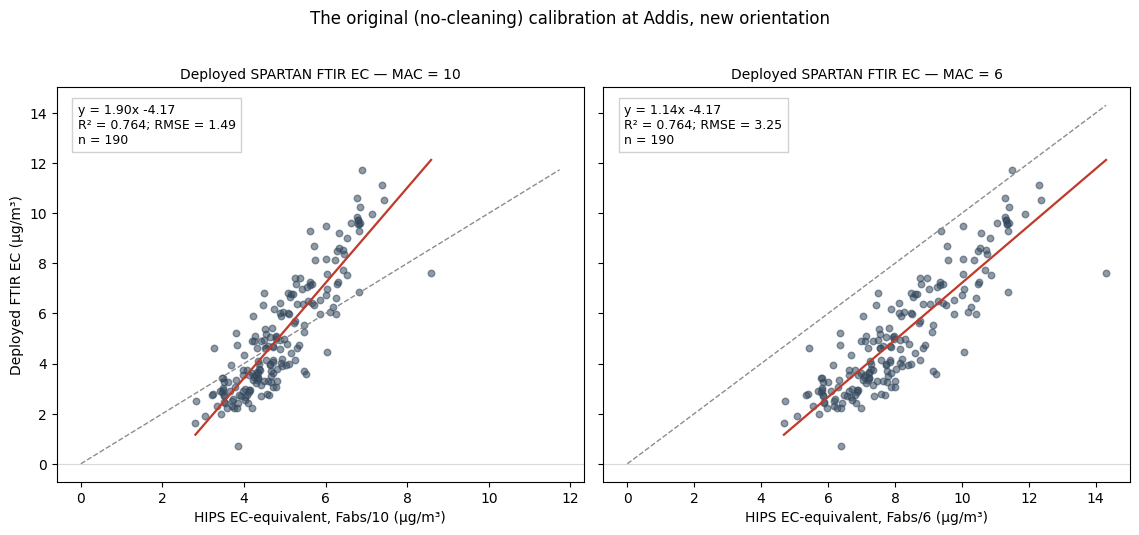

In [3]:
alldata_mask = fixed_mask & np.isfinite(deployed) & np.isfinite(fabs)
alldata_rows = []
for mac in (10, 6):
    stats = regression_metrics(fabs[alldata_mask] / mac, deployed[alldata_mask])
    alldata_rows.append({'panel': f'MAC = {mac}', 'MAC_m2_g': mac, **stats})
alldata = pd.DataFrame(alldata_rows)
alldata.to_csv(TABLE_DIR / 'deployed_alldata_metrics.csv', index=False)
display(alldata)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), sharey=True)
for ax, mac in zip(axes.flat, (10, 6)):
    x, y = fabs[alldata_mask] / mac, deployed[alldata_mask]
    stats = regression_metrics(x, y)
    ax.scatter(x, y, s=22, alpha=.55, color='#34495E')
    hi = max(np.nanmax(x), np.nanmax(y))
    ax.plot([0, hi], [0, hi], '--', color='0.55', lw=1, label='1:1')
    fit_x = np.array([np.nanmin(x), np.nanmax(x)])
    ax.plot(fit_x, stats['slope'] * fit_x + stats['intercept'], color='#C0392B', lw=1.6)
    ax.axhline(0, color='0.85', lw=.8, zorder=0)
    ax.set_title(f'Deployed SPARTAN FTIR EC — MAC = {mac}', fontsize=10)
    ax.text(.04, .96, f'y = {stats["slope"]:.2f}x {stats["intercept"]:+.2f}\n'
                      f'R² = {stats["R2"]:.3f}; RMSE = {stats["RMSE"]:.2f}\nn = {stats["n"]}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='0.8', alpha=.9))
    ax.set_xlabel(f'HIPS EC-equivalent, Fabs/{mac} (µg/m³)')
axes[0].set_ylabel('Deployed FTIR EC (µg/m³)')
fig.suptitle('The original (no-cleaning) calibration at Addis, new orientation', y=1.02)
fig.tight_layout()
for target in (PLOT_DIR / 'deployed_alldata_crossplot.png',
               DECK_DIR / 'deployed_alldata_crossplot.png'):
    fig.savefig(target, dpi=180, bbox_inches='tight')
plt.show()

### 3. No-cleaning full-pool TOR calibration (protocol-matched)

The deployed model is "no cleaning" in spirit but was trained outside our protocol. Here we
train on **every eligible lot-248/251 filter** — TOR EC loading available, corrected
spectrum in the cache, one spectrum per filter, no compositional or spectral selection —
under the locked site-disjoint split, raw (k = 6) and AIRSpec df1 = 6 (k = 5).

No-cleaning cohort: 13010 filters, 158 sites


,model,k,MAC_m2_g,heldout_TOR_R2,heldout_TOR_slope,heldout_TOR_RMSE,addis_n,addis_slope,addis_intercept,addis_R2,addis_RMSE,addis_MAE,addis_bias,addis_median_bias
0,full pool raw,6,10,0.526665,0.699027,6.730555,190,0.659696,-1.326800,0.745141,3.039239,2.989859,-2.989859,-2.981253
1,full pool raw,6,6,0.526665,0.699027,6.730555,190,0.395817,-1.326800,0.745141,6.351666,6.247843,-6.247843,-6.177055
2,full pool AIRSpec df1=6,5,10,0.633327,0.711201,5.665218,190,0.396951,-0.607895,0.601994,3.628250,3.554983,-3.554983,-3.493966
3,full pool AIRSpec df1=6,5,6,0.633327,0.711201,5.665218,190,0.238170,-0.607895,0.601994,6.953223,6.812967,-6.812967,-6.652355


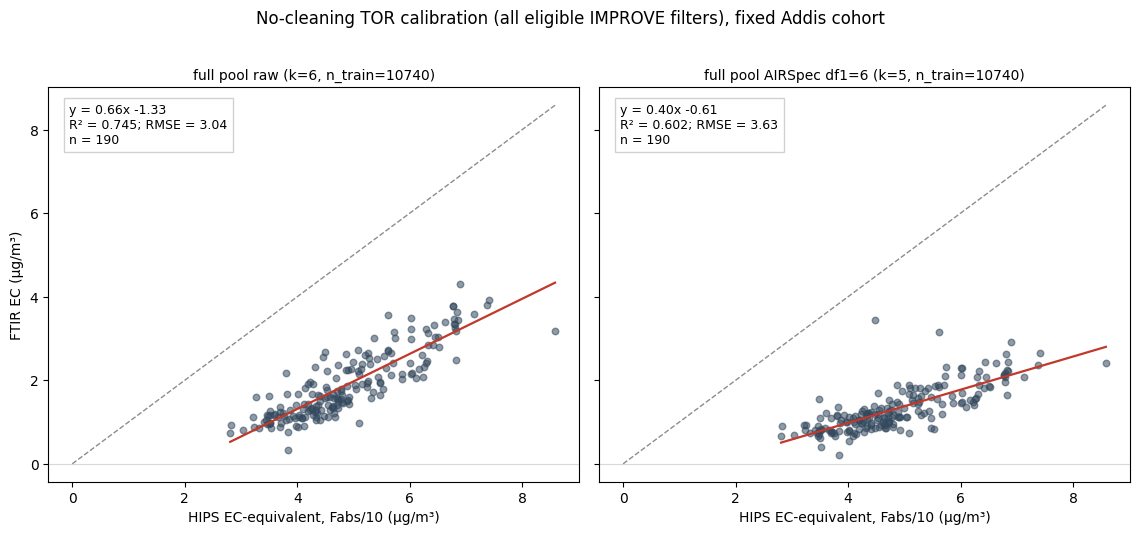

In [4]:
pool_meta = load_pool_metadata().merge(load_tor_loadings(), on=['Site', 'date'],
                                       how='left', validate='many_to_one')
eligible = pool_meta[
    pool_meta['TOR_EC_loading_ug'].gt(0)
    & pool_meta['AnalysisId'].astype(int).isin(pool_row_for_id)
    & pool_meta['AnalysisId'].astype(int).isin(pool_raw.index)
].drop_duplicates('FilterId').copy()
analysis_ids = eligible['AnalysisId'].astype(int).to_numpy()
y_pool = eligible['TOR_EC_loading_ug'].to_numpy(float)
sites_pool = eligible['Site'].to_numpy()
print(f'No-cleaning cohort: {len(eligible)} filters, {eligible.Site.nunique()} sites')

X_pool_raw = pool_raw.loc[analysis_ids, wcols].to_numpy(float)
X_pool_corr = pool_npz['corrected'][[pool_row_for_id[a] for a in analysis_ids]].astype(float)

train_pos, test_pos = next(GroupShuffleSplit(
    n_splits=1, test_size=.20, random_state=SPLIT_SEED).split(eligible, groups=sites_pool))
assert set(sites_pool[train_pos]).isdisjoint(sites_pool[test_pos])

fullpool_rows, fullpool_addis = [], {}
for label, X, X_addis, k in (
        ('full pool raw', X_pool_raw, X_etad_raw, K_RAW),
        ('full pool AIRSpec df1=6', X_pool_corr, X_addis_corr, K_CORRECTED)):
    model = PLSRegression(n_components=k, scale=False).fit(X[train_pos], y_pool[train_pos])
    heldout = regression_metrics(y_pool[test_pos], model.predict(X[test_pos]).ravel())
    addis_ugm3 = model.predict(X_addis).ravel() / volume
    fullpool_addis[label] = addis_ugm3
    for mac in (10, 6):
        fullpool_rows.append({
            'model': label, 'k': k, 'MAC_m2_g': mac,
            'heldout_TOR_R2': heldout['R2'], 'heldout_TOR_slope': heldout['slope'],
            'heldout_TOR_RMSE': heldout['RMSE'],
            **{f'addis_{key}': value for key, value in regression_metrics(
                fabs[fixed_mask] / mac, addis_ugm3[fixed_mask]).items()},
        })
fullpool = pd.DataFrame(fullpool_rows)
fullpool.to_csv(TABLE_DIR / 'no_cleaning_fullpool_metrics.csv', index=False)
display(fullpool)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), sharex=True, sharey=True)
x = fabs[fixed_mask] / 10
for ax, (label, addis_ugm3) in zip(axes.flat, fullpool_addis.items()):
    y = addis_ugm3[fixed_mask]
    stats = regression_metrics(x, y)
    ax.scatter(x, y, s=22, alpha=.55, color='#34495E')
    hi = max(np.nanmax(x), np.nanmax(y))
    ax.plot([0, hi], [0, hi], '--', color='0.55', lw=1)
    fit_x = np.array([np.nanmin(x), np.nanmax(x)])
    ax.plot(fit_x, stats['slope'] * fit_x + stats['intercept'], color='#C0392B', lw=1.6)
    ax.axhline(0, color='0.85', lw=.8, zorder=0)
    ax.set_title(f'{label} (k={K_RAW if "raw" in label else K_CORRECTED}, '
                 f'n_train={len(train_pos)})', fontsize=10)
    ax.text(.04, .96, f'y = {stats["slope"]:.2f}x {stats["intercept"]:+.2f}\n'
                      f'R² = {stats["R2"]:.3f}; RMSE = {stats["RMSE"]:.2f}\nn = {stats["n"]}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='0.8', alpha=.9))
    ax.set_xlabel('HIPS EC-equivalent, Fabs/10 (µg/m³)')
axes[0].set_ylabel('FTIR EC (µg/m³)')
fig.suptitle('No-cleaning TOR calibration (all eligible IMPROVE filters), fixed Addis cohort',
             y=1.02)
fig.tight_layout()
for target in (PLOT_DIR / 'no_cleaning_fullpool_crossplots.png',
               DECK_DIR / 'no_cleaning_fullpool_crossplots.png'):
    fig.savefig(target, dpi=180, bbox_inches='tight')
plt.show()

### 4. Full-range spectra, IMPROVE vs Addis, side by side

Median spectra (IQR band for Addis and the full pool) on the raw grid — offset-corrected
only, so the baselines the AIRSpec step removes are visible — next to the AIRSpec df1 = 6
corrected grid (1426–3998 cm⁻¹). Top row absolute; bottom row each spectrum normalized by
its own CH peak height so shape differences separate from loading differences.

,group,n_raw,n_corrected
0,Addis,296,296
1,IMPROVE full pool,13634,13634
2,Lowest-OCEC 800,800,800
3,Smoke 906,906,906


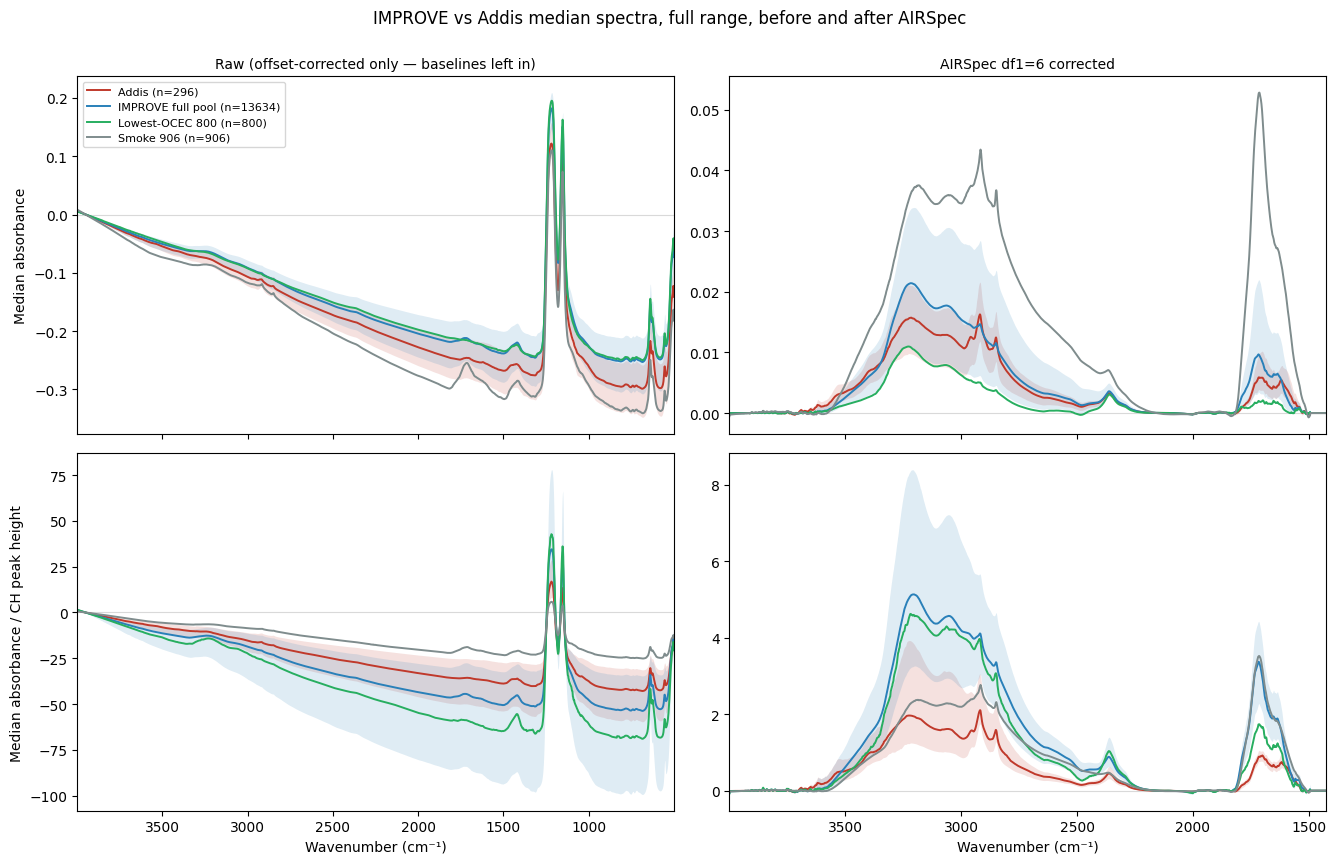

In [5]:
smoke_in_pool = [int(v) for v in smoke.analysis_ids if int(v) in pool_row_for_id]
groups_raw = {
    'Addis': X_addis_all_raw,
    'IMPROVE full pool': pool_raw[wcols].to_numpy(np.float32),
    'Lowest-OCEC 800': pool_raw.loc[
        [a for a in ocec['AnalysisId'].astype(int) if a in pool_raw.index], wcols
    ].to_numpy(np.float32),
    'Smoke 906': smoke.X,
}
etad_all_in_cache = etad_all[etad_all['MediaId'].isin(etad_corr_by_media.index)]
groups_corr = {
    'Addis': etad_corr_by_media.loc[etad_all_in_cache['MediaId']].to_numpy(float),
    'IMPROVE full pool': pool_npz['corrected'].astype(np.float32),
    'Lowest-OCEC 800': pool_npz['corrected'][
        [pool_row_for_id[a] for a in ocec['AnalysisId'].astype(int)
         if a in pool_row_for_id]].astype(np.float32),
    'Smoke 906': pool_npz['corrected'][
        [pool_row_for_id[a] for a in smoke_in_pool]].astype(np.float32),
}
audit = pd.DataFrame([{'group': name, 'n_raw': len(groups_raw[name]),
                       'n_corrected': len(groups_corr[name])} for name in groups_raw])
audit.to_csv(TABLE_DIR / 'spectra_group_audit.csv', index=False)
display(audit)

CH_FLOOR = 1e-3


def ch_normalized(X, wavenumbers):
    ch = local_continuum_peak_height(
        np.asarray(X, float), wavenumbers, (2800, 3000), (3050, 3150), (2650, 2750))
    keep = ch > CH_FLOOR
    return np.asarray(X, float)[keep] / ch[keep, None]


fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.6), sharex='col')
for column, (grid, groups, corrected) in enumerate((
        (wn, {k: offset_correct(np.asarray(v, float), wn) for k, v in groups_raw.items()},
         False),
        (wn_corr, {k: np.asarray(v, float) for k, v in groups_corr.items()}, True))):
    for row, normalize in enumerate((False, True)):
        ax = axes[row, column]
        for name, X in groups.items():
            Xp = ch_normalized(X, grid) if normalize else X
            median = np.median(Xp, axis=0)
            ax.plot(grid, median, lw=1.4, color=GROUP_COLORS[name],
                    label=f'{name} (n={len(Xp)})')
            if name in ('Addis', 'IMPROVE full pool'):
                ax.fill_between(grid, np.percentile(Xp, 25, axis=0),
                                np.percentile(Xp, 75, axis=0),
                                color=GROUP_COLORS[name], alpha=.15, lw=0)
        ax.axhline(0, color='0.85', lw=.8, zorder=0)
        ax.set_xlim(grid.max(), grid.min())
        if row == 0:
            ax.set_title('AIRSpec df1=6 corrected' if corrected
                         else 'Raw (offset-corrected only — baselines left in)', fontsize=10)
        else:
            ax.set_xlabel('Wavenumber (cm⁻¹)')
axes[0, 0].set_ylabel('Median absorbance')
axes[1, 0].set_ylabel('Median absorbance / CH peak height')
axes[0, 0].legend(fontsize=8, loc='upper left')
fig.suptitle('IMPROVE vs Addis median spectra, full range, before and after AIRSpec', y=1.0)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'improve_vs_addis_spectra_side_by_side.png', dpi=180,
            bbox_inches='tight')
plt.show()

### 5. Addis spectra by Naveed's seasons

Same two spectral bases, split Dry (Oct–Feb) / Belg (Mar–May) / Kiremt (Jun–Sep). The
table adds the ftir_12 band diagnostics per season (offset-corrected raw convention) plus
deployed EC and HIPS Fabs medians for the HIPS-paired subset.

,n_spectra,n_hips_paired,band1600_center_median,band1600_height_median,CH_peak_median,carbonyl_peak_median,band1600_to_CH_median,deployed_EC_median_ugm3,Fabs_median
season,,,,,,,,,
Dry (Oct-Feb),118,105,1618.6543,0.0032,0.0053,0.0038,0.6244,3.2727,43.1756
Belg (Mar-May),62,61,1617.3686,0.0058,0.0076,0.0056,0.7537,4.7604,47.1103
Kiremt (Jun-Sep),73,73,1617.3686,0.0083,0.0133,0.0100,0.6373,7.1557,56.1327


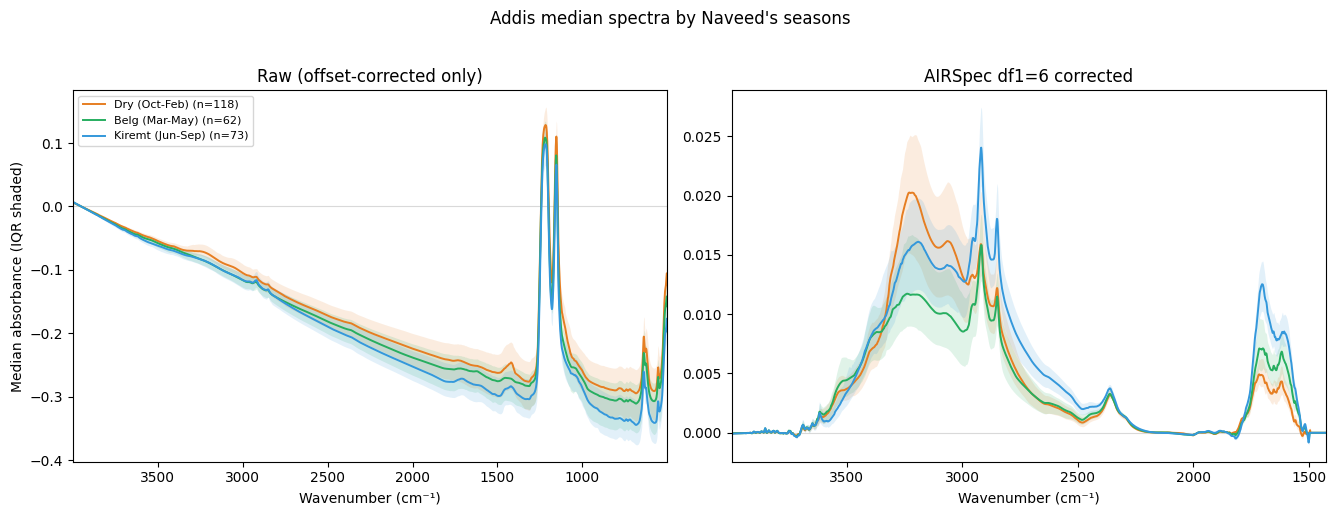

In [6]:
season_rows = []
X_addis_offset = offset_correct(X_addis_all_raw, wn)
center, height_1600, edge_hit = band_center(X_addis_offset, wn)
ch_all = local_continuum_peak_height(X_addis_offset, wn, (2800, 3000), (3050, 3150),
                                     (2650, 2750))
carbonyl_all = local_continuum_peak_height(X_addis_offset, wn, (1650, 1775), (1800, 1900),
                                           (1500, 1550))
band_frame = etad_all[['MediaId', 'season']].copy()
band_frame['band1600_center'] = np.where(edge_hit, np.nan, center)
band_frame['band1600_height'] = height_1600
band_frame['CH_peak'] = ch_all
band_frame['carbonyl_peak'] = carbonyl_all
band_frame = band_frame.merge(
    etad_eval[['MediaId', 'EC_deployed_ugm3', 'Fabs']], on='MediaId', how='left')

for season, group in band_frame.groupby('season'):
    season_rows.append({
        'season': season, 'n_spectra': len(group),
        'n_hips_paired': int(group['Fabs'].notna().sum()),
        'band1600_center_median': group['band1600_center'].median(),
        'band1600_height_median': group['band1600_height'].median(),
        'CH_peak_median': group['CH_peak'].median(),
        'carbonyl_peak_median': group['carbonyl_peak'].median(),
        'band1600_to_CH_median': (group['band1600_height'] / group['CH_peak']
                                  .where(group['CH_peak'] > 1e-4)).median(),
        'deployed_EC_median_ugm3': group['EC_deployed_ugm3'].median(),
        'Fabs_median': group['Fabs'].median(),
    })
seasonal = pd.DataFrame(season_rows).set_index('season').loc[list(ETHIOPIA_SEASONS)]
seasonal.to_csv(TABLE_DIR / 'addis_seasonal_band_metrics.csv')
display(seasonal.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
for ax, (grid, frame, X, title) in zip(axes.flat, (
        (wn, etad_all, X_addis_offset, 'Raw (offset-corrected only)'),
        (wn_corr, etad_all_in_cache,
         etad_corr_by_media.loc[etad_all_in_cache['MediaId']].to_numpy(float),
         'AIRSpec df1=6 corrected'))):
    for season, info in ETHIOPIA_SEASONS.items():
        keep = frame['season'].eq(season).to_numpy()
        if keep.any():
            ax.plot(grid, np.median(X[keep], axis=0), lw=1.4, color=info['color'],
                    label=f'{season} (n={int(keep.sum())})')
            ax.fill_between(grid, np.percentile(X[keep], 25, axis=0),
                            np.percentile(X[keep], 75, axis=0),
                            color=info['color'], alpha=.14, lw=0)
    ax.axhline(0, color='0.85', lw=.8, zorder=0)
    ax.set_xlim(grid.max(), grid.min())
    ax.set(xlabel='Wavenumber (cm⁻¹)', title=title)
axes[0].set_ylabel('Median absorbance (IQR shaded)')
axes[0].legend(fontsize=8)
fig.suptitle("Addis median spectra by Naveed's seasons", y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'addis_spectra_by_season.png', dpi=180, bbox_inches='tight')
plt.show()

## Takeaways

- **Deck gap closed.** `deployed_alldata_crossplot.png` and
  `no_cleaning_fullpool_crossplots.png` are in `output/plots/deck/` alongside the intercept
  ladder; the original calibration's real slope/intercept (1.90/−4.17 at MAC = 10,
  1.14/−4.17 at MAC = 6) can be read straight off the plot.
- **"No cleaning" is now a measured baseline, not a hypothetical.** Its near-zero intercepts
  come with collapsed slopes and degraded TOR tests — the full-pool version of the
  random-cohort trap — so the OCEC-800 selection is defended from both directions
  (better than smoke-906 *and* better than no selection at all).
- **Addis's spectral signature is a deficit, not an exotic peak.** Per unit CH it carries
  about half the oxygenated (O–H, carbonyl) absorption of any IMPROVE cohort and falls
  below the 13.6k pool's IQR — supporting the view that IMPROVE simply lacks
  charcoal-like, oxygenation-poor samples rather than Addis having features IMPROVE spectra
  can't express.
- **The 1600-band identity is not a seasonal artifact**: its center is 1617–1619 cm⁻¹ in
  Dry, Belg, and Kiremt alike, and composition ratios barely move across seasons — consistent
  with ftir_15's season-stable corrected offset. Season mainly modulates loading (all bands,
  EC, and Fabs peak in Kiremt), with a relative Dry-season enhancement of the broad O–H band
  as the one shape change.
- **Caveat**: the full-pool models use the locked k from ftir_11/13 (6 raw, 5 corrected) as
  fixed-k sensitivity, not a fresh CV selection; and 43 of 296 Addis spectra lack sampling
  dates and are excluded from the seasonal split.